In [1]:
import os
import sys
import gc
os.chdir('/zhome/71/c/146676/texture_tomography')
import h5py
import numpy as np
from pathlib import Path

from diffractom.operators.pfo_single_material import PFO_SINGLE, estimate_L_power


import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml



from diffractom.optimization.fista_opencl import FISTAOpenCL
from diffractom.optimization.fista_huber_opencl import FISTAHuberOpenCL
from diffractom.gpu_live_tracker import GPUMemoryLogger
from diffractom.operators.memory_tracker import MemoryCounter
import pyopencl.array as clarray
from diffractom.multiresolution_refiner import OrientationTree, invert_grid
from diffractom.material import Material
from scipy.spatial.transform import Rotation as R

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d


INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
config_path = "configs/aluminum_config_single.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

N_eta = cfg['N_eta']
N_Omega = cfg['N_Omega']
N_theta = cfg['N_theta']
Nx = cfg['Nx']
Ny = cfg['Ny']
datapath = cfg["datapath"]
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']
filename = datapath + filename_integrated

In [3]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)


path = cif_folder / filenames[0]
material = Material.from_cif(
    cif_path=path,
    wavelength_kev=wavelength_kev,
    min_two_theta=min_two_theta,
    max_two_theta=max_two_theta,
    intensity_cutoff_fraction=reflection_cutoff,
)


import h5py, hdf5plugin
with h5py.File("/work3/msaca/basis_set.h5", "r") as f:
    # Rotation matrices (shape: N, 3, 3) in Orix convention but as numpy array.
    numpy_orien = f["numpy_orien"][::100]

    # Number of peaks that each orientation could index uniquely from the data.
    scores = f["scores"][...]

grid = OrientationTree.from_rotation_matrices(
    numpy_orien[:],
    sigma=0.02,
)


In [4]:
op = PFO_SINGLE(
        cfg = cfg,
        material=material,
        grid=grid,
        max_gb=0.6,
        verbose=True,
        normalized = True,)



=== OpenCL buffer allocation summary ===
coeffs_sino_F                 : shape=(148x500x357),   100.78 MB
coeffs_sino_C                 : shape=(500x148x357),   100.78 MB
_coeffs_batch_F               : shape=(148x148x357),    29.83 MB
_basis_batch_kmax             : shape=(500x357x180x5),   612.83 MB
_basis_batch_transpose_kmax   : shape=(500x900x357),   612.83 MB
_grid_inv_kmax                : shape=(357x9),     0.01 MB
_inv_sigma2_kmax              : shape=(357),     0.00 MB
_norm_factor_kmax             : shape=(357),     0.00 MB
---------------------------------------
TOTAL GPU buffer memory:  1457.06 MB



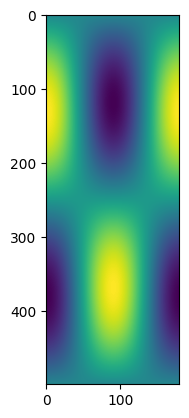

In [5]:
coords = op.coords_cpu
plt.imshow(coords[:,:,0,0])

In [19]:
wavelength_angstrom = 12.398 / op.cfg["wavelength"]

j0 = np.asarray(op.cfg["j_direction_0"])
k0 = np.asarray(op.cfg["k_direction_0"])
p0 = np.asarray(op.cfg["p_direction_0"])
det_o = np.asarray(op.cfg["detector_direction_origin"])
det_p90 = np.asarray(op.cfg["detector_direction_positive_90"])

# ---------------- rotations ----------------
projections = {
    str(i): {
        "rotation_matrix": R.from_rotvec(
            angle * k0 / np.linalg.norm(k0)
        ).as_matrix()
    }
    for i, angle in enumerate(op.angles)
}

detector_angles = np.linspace(0, 2*np.pi, op.N_eta, endpoint=False)


geom_dict = {
    "projections": projections,
    "p_direction_0": p0,
    "j_direction_0": j0,
    "k_direction_0": k0,
    "detector_direction_origin": det_o,
    "detector_direction_positive_90": det_p90,
    "detector_angles": detector_angles,
}


two_theta_peaks = 2.0 * np.arcsin(
    np.linalg.norm(op.h_cpu, axis=1) / (4.0 * np.pi) * wavelength_angstrom
).astype(np.float32)
print(wavelength_angstrom)
print(two_theta_peaks)

# ---------------- probed coordinates ----------------
coords_list = []
for tt in two_theta_peaks:
    geom_dict["two_theta"] = np.array([tt])
    geom = GeometryContainerM(
        dictionary=geom_dict,
        data_type="dictionary"
    ).geometry
    coords = get_probed_coordinates(geom)[:, :, 0, :]
    coords_list.append(coords)

#coords_cpu = np.stack(coords_list, axis=-1)
#coords_cpu = coords_cpu.transpose((0, 1, 3, 2))
#np.asarray(coords_cpu, dtype=np.float32, order="C")
#clarray.to_device(op.queue, self.coords_cpu)


0.3562848439565492
[0.15253486 0.17618918 0.24949357 0.29284424 0.3858888 ]


In [23]:
print(geom)
print(len(geom))
n_seg = len(geom.detector_angles)
print(n_seg)

--------------------------------------------------------------------------
                                 Geometry                                 
--------------------------------------------------------------------------
hash_rotations     : 91b3b5
hash_j_offsets     : 8da62c
hash_k_offsets     : 8da62c
p_direction_0      : [1. 0. 0.]
j_direction_0      : [ 0. -1.  0.]
k_direction_0      : [0. 0. 1.]
hash_inner_angles  : 786a02
hash_outer_angles  : 014897
hash_inner_axes    : 407101
hash_outer_axes    : 608e66
detector_direction_origin : [0. 1. 0.]
detector_direction_positive_90 : [0. 0. 1.]
two_theta          : [22.11]°
projection_shape   : [0 0]
volume_shape       : [0 0 0]
detector_angles    : [0.    ... 6.248]
full_circle_covered : True
--------------------------------------------------------------------------
500
180


In [28]:
geom.detector_direction_origin[:]

array([0., 1., 0.])

In [ ]:
np.array(op.cfg["detector_direction_positive_90"][:])

array([0, 0, 1])

In [39]:
op.cfg["k_direction_0"]

[0, 0, 1]

In [48]:
print(projections['0'])

{'rotation_matrix': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])}


In [50]:
k0 = np.asarray(op.cfg["k_direction_0"])
Rmats = R.from_rotvec(op.angles[:, None] * k0).as_matrix()

In [57]:
print(Rmats.shape)
print(geom.rotations_as_array.shape)

(500, 3, 3)
(500, 3, 3)


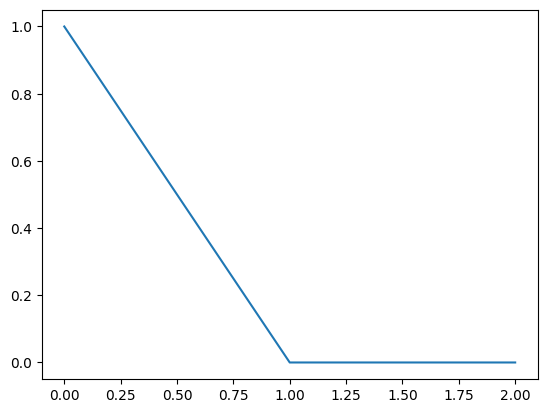

In [53]:
plt.plot(Rmats[0,0])

In [46]:
print(np.stack(projections).shape)
plt.plot(np.stack(projections)[0,0])


(500,)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

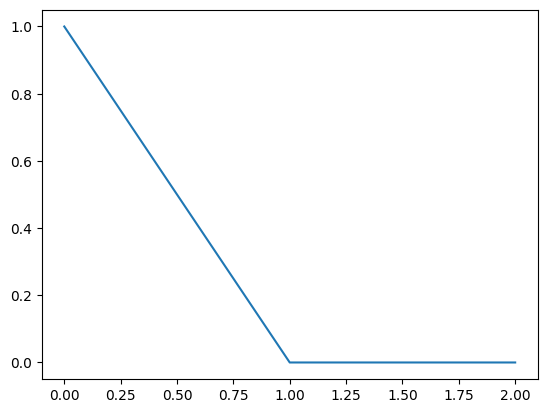

In [44]:
plt.plot(np.stack(geom.rotations)[0,0])


In [62]:
geom.detector_angles
print(len(op.angles))

500
